In [1]:
from SystematicScanOfConvergence.MakeHam import *
from Permutations.Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from Permutations.SKQD import *
from Permutations.PowerSampling import *
from Permutations.CSRtoSPO import *
from BARK import *
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import tqdm
from scipy.sparse import csr_matrix
from qiskit.quantum_info import Operator
from qiskit.quantum_info import SparsePauliOp
from SystematicScanOfConvergence.MakeHam import make_sparse_ground_state_hamiltonian_from_qubits

### Create Hamiltonian with sparse groundstate

In [2]:
H, psi, sup = make_sparse_ground_state_hamiltonian_from_qubits(8, 25, ground_energy=-5, gap =1, return_sparse=True)

In [3]:
op = Operator(H.toarray())
H_spo = SparsePauliOp.from_operator(op)
correct_energy, correct_state = eigsh(H, k=1, which='SA')

In [4]:
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
sparsity = np.sum(amps > 1e-4) / len(amps)
print(f"Sparsity of the correct ground state: {sparsity:.4f}")

Sparsity of the correct ground state: 0.0977


## SKQD

In [5]:
n_steps = 16
initial = np.argmax(amps)

initial_state = np.zeros(H.shape[0])
initial_state[initial] = 1

print(f"Initial overlap with correct state: {np.abs(np.dot(correct_state[:, 0].conj(), initial_state)):.4f}")

Initial overlap with correct state: 0.4105


In [ ]:
print(initial)

In [6]:
skqd_list0001 = do_skqd(H, n_steps, t = 0.001, initial=initial)
skqd_list001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list01 = do_skqd(H, n_steps, t = 0.1, initial=initial)
skqd_list02 = do_skqd(H, n_steps, t = 0.2, initial=initial)
skqd_list03 = do_skqd(H, n_steps, t = 0.3, initial=initial)
skqd_list04 = do_skqd(H, n_steps, t = 0.4, initial=initial)
skqd_list05 = do_skqd(H, n_steps, t = 0.5, initial=initial)
skqd_list06 = do_skqd(H, n_steps, t = 0.6, initial=initial)
skqd_list07 = do_skqd(H, n_steps, t = 0.7, initial=initial)
skqd_list08 = do_skqd(H, n_steps, t = 0.8, initial=initial)
skqd_list09 = do_skqd(H, n_steps, t = 0.9, initial=initial)
skqd_list10 = do_skqd(H, n_steps, t = 1.0, initial=initial)

c:\Users\jeisinge.UNI-MAINZ\.conda\envs\sampling_bits\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\jeisinge.UNI-MAINZ\.conda\envs\sampling_bits\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
100%|██████████| 16/16 [00:00<00:00, 898.04it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1111.44it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 738.71it/s]


...

No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 899.74it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 786.33it/s]

No more indices left to sample.


In [18]:
print(type(H), type(skqd_list0001))

<class 'scipy.sparse._csr.csr_matrix'> <class 'numpy.ndarray'>


In [7]:
skqd_path01 = get_one_path(H, skqd_list01)
skqd_path02 = get_one_path(H, skqd_list02)
skqd_path03 = get_one_path(H, skqd_list03)
skqd_path04 = get_one_path(H, skqd_list04)
skqd_path05 = get_one_path(H, skqd_list05)
skqd_path06 = get_one_path(H, skqd_list06)
skqd_path07 = get_one_path(H, skqd_list07)
skqd_path08 = get_one_path(H, skqd_list08)
skqd_path09 = get_one_path(H, skqd_list09)
skqd_path10 = get_one_path(H, skqd_list10)
skqd_path001 = get_one_path(H, skqd_list001)
skqd_path0001 = get_one_path(H, skqd_list0001)

In [8]:
# Helpers

def bitstrings_to_indices(basis: List[str]) -> List[int]:
    return [int(b, 2) for b in basis]

def get_one_path_from_BK(basis_list: List[str]) -> List[str]:
    energies = []
    for pos in tqdm.tqdm(range(len(basis_list))):
        current_basis = basis_list[:pos+1]
        indices = bitstrings_to_indices(current_basis)
        H_proj = project_down(H, indices)

        if pos > 2:
            energies.append(eigsh(H_proj, k=1, which='SA', return_eigenvectors=False)[0])
        else:
            energies.append(eigh(H_proj.toarray(), eigvals_only=True)[0])

    return energies

## Bark 2.0

In [9]:
from Permutations.Bark_2_0 import BarkBarkBark

In [10]:
# get initial state for bark
initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')

In [ ]:
print(initial_bark)
# print(initial_state)

01011101
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [11]:
explorer = BarkBarkBark(
    H=H_spo,
    initial_state=initial_bark,
    keep_states=50,            # M
    max_applications=5,      # number of H-applications to selected batches
    mode="top_m",             # or "importance_sample"
    sample_size=1,           # only used for importance_sample
    sampling_score="amplitude",
    return_only_applied_bitstrings=True,
    random_seed=123,
)

bitstrings = explorer.run()
print(len(bitstrings))

print(bitstrings)

250
['01011101', '11101100', '11010001', '01100111', '01110001', '00010110', '01111101', '01111111', '10110100', '11001000', '00111001', '00110000', '01011000', '10000010', '11101101', '01111001', '00001100', '00011000', '00101000', '00001111', '11001011', '00100111', '11111000', '10110011', '00000111', '01101110', '11110010', '01111011', '01101011', '10000100', '10011010', '11000010', '10110000', '10111010', '01001110', '00110100', '01010111', '01010011', '01100010', '01111010', '10001001', '01110100', '01001000', '00011111', '01111110', '10111011', '10100110', '00101111', '10010010', '00101100', '10110001', '10010110', '01010001', '01001100', '00010100', '10101011', '11110001', '01101111', '10100010', '11110100', '11110101', '10101100', '00101110', '10111100', '10011111', '10101000', '11101110', '10110101', '00000010', '01110000', '11011101', '01110101', '10001000', '01101001', '00001001', '00110010', '00101011', '01000001', '11001010', '01000111', '11000111', '10011001', '00001011',

### Get the BARK path

In [12]:
BK_BK_BK_path = get_one_path_from_BK(bitstrings)

100%|██████████| 250/250 [00:01<00:00, 131.79it/s]


### Get the random paths

In [13]:
Paths = get_all_paths(H, 20, initial)

Computing paths: 100%|██████████| 20/20 [00:50<00:00,  2.55s/it]


## Plot

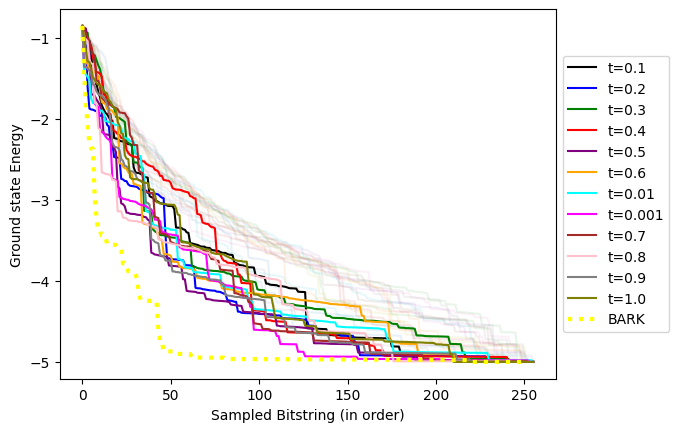

In [14]:
i = 0
for path in Paths:
    plt.plot(path, alpha=0.1)
    i += 1
plt.plot(skqd_path01, label='t=0.1', color='black')
plt.plot(skqd_path02, label='t=0.2', color='blue')
plt.plot(skqd_path03, label='t=0.3', color='green')
plt.plot(skqd_path04, label='t=0.4', color='red')
plt.plot(skqd_path05, label='t=0.5', color='purple')
plt.plot(skqd_path06, label='t=0.6', color='orange')
plt.plot(skqd_path001, label='t=0.01', color='cyan')
plt.plot(skqd_path0001, label='t=0.001', color='magenta')
plt.plot(skqd_path07, label='t=0.7', color='brown')
plt.plot(skqd_path08, label='t=0.8', color='pink')
plt.plot(skqd_path09, label='t=0.9', color='gray')
plt.plot(skqd_path10, label='t=1.0', color='olive')
# plt.plot(power_path, label='Power Sampling', color='purple', linestyle='dashed')
# plt.plot(BK_path, label='BARK', color='purple', linestyle='dotted')
plt.plot(BK_BK_BK_path, label='BARK', color='yellow',linewidth=3.0, linestyle='dotted')
# Make legend next to plot
plt.ylabel('Ground state Energy')
plt.xlabel('Sampled Bitstring (in order)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [15]:
import os

img_path = os.path.join(os.getcwd(), "SystematicScanOfConvergence/dog.png")
img = plt.imread(img_path)

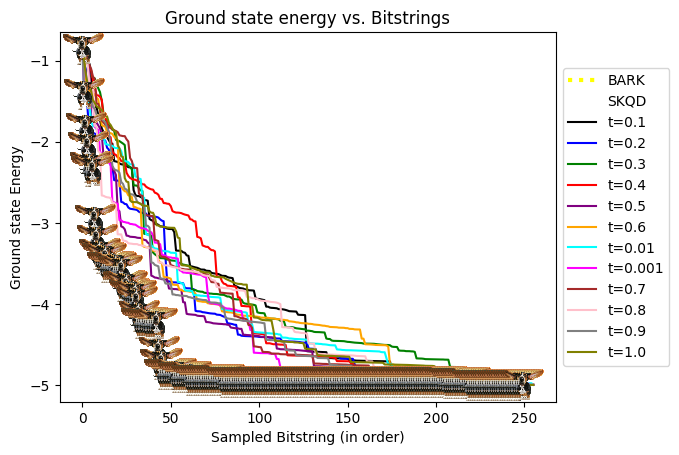

In [16]:
from matplotlib.lines import Line2D

# --- your plotting stays the same ---
plt.plot(skqd_path01, color='black')
plt.plot(skqd_path02, color='blue')
plt.plot(skqd_path03, color='green')
plt.plot(skqd_path04, color='red')
plt.plot(skqd_path05, color='purple')
plt.plot(skqd_path06, color='orange')
plt.plot(skqd_path001, color='cyan')
plt.plot(skqd_path0001, color='magenta')
plt.plot(skqd_path07, color='brown')
plt.plot(skqd_path08, color='pink')
plt.plot(skqd_path09, color='gray')
plt.plot(skqd_path10, color='olive')
plt.ylabel('Ground state Energy')
plt.xlabel('Sampled Bitstring (in order)')
plt.title('Ground state energy vs. Bitstrings')
# plt.plot(BK_BK_BK_path, label='BARK', color='yellow', linewidth=3.0, linestyle='dotted')
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# img = plt.imread("C:\Users\jeisinge.UNI-MAINZ\Projects\Emil\informed_swapping\SystematicScanOfConvergence\dog.png")  # transparent PNG works best

y = BK_BK_BK_path
x = range(len(y))

for xi, yi in zip(x, y):
    ab = AnnotationBbox(
        OffsetImage(img, zoom=0.03),
        (xi, yi),
        frameon=False
    )
    plt.gca().add_artist(ab)

# legend proxy
plt.plot([], [], label='BARK', color='yellow', linestyle='dotted')

# --- custom legend ---
skqd_header = Line2D([], [], color='none', label='SKQD')

skqd_handles = [
    Line2D([], [], color='black', label='t=0.1'),
    Line2D([], [], color='blue', label='t=0.2'),
    Line2D([], [], color='green', label='t=0.3'),
    Line2D([], [], color='red', label='t=0.4'),
    Line2D([], [], color='purple', label='t=0.5'),
    Line2D([], [], color='orange', label='t=0.6'),
    Line2D([], [], color='cyan', label='t=0.01'),
    Line2D([], [], color='magenta', label='t=0.001'),
    Line2D([], [], color='brown', label='t=0.7'),
    Line2D([], [], color='pink', label='t=0.8'),
    Line2D([], [], color='gray', label='t=0.9'),
    Line2D([], [], color='olive', label='t=1.0'),
]

from matplotlib.offsetbox import OffsetImage
from matplotlib.legend_handler import HandlerBase

class ImageHandler(HandlerBase):
    def __init__(self, img, zoom=0.05):
        self.img = img
        self.zoom = zoom
        super().__init__()

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        image = OffsetImage(self.img, zoom=self.zoom)
        image.set_transform(trans)
        image.set_offset((width/2, height/2))
        return [image]

dog_handle = object()

plt.legend(
    [dog_handle],
    ['BARK'],
    handler_map={dog_handle: ImageHandler(img, zoom=0.03)},
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

bark_handle = Line2D([], [], color='yellow', linestyle='dotted', linewidth=3.0, label='BARK')

handles = [bark_handle] + [skqd_header] + skqd_handles

plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))

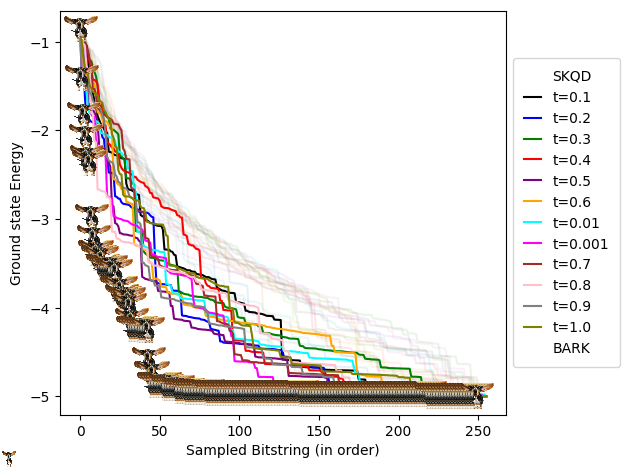

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, DrawingArea
from matplotlib.legend_handler import HandlerBase
from matplotlib.image import BboxImage
from matplotlib.transforms import Bbox

# ---------------- custom legend handler for dog image ----------------
class DogHandler(HandlerBase):
    def __init__(self, img, size=22):
        super().__init__()
        self.img = img
        self.size = size  # pixels in legend

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        da = DrawingArea(self.size, self.size, 0, 0)
        bbox = Bbox.from_bounds(0, 0, self.size, self.size)
        image = BboxImage(bbox, interpolation="bilinear")
        image.set_data(self.img)
        da.add_artist(image)
        return [da]

# ---------------- load dog image ----------------
img_path = os.path.join(os.getcwd(), "SystematicScanOfConvergence/dog.png")
dog_img = mpimg.imread(img_path)

# ---------------- make figure ----------------
fig, ax = plt.subplots()

# ---------------- plot all background paths ----------------
for path in Paths:
    ax.plot(path, alpha=0.1)

# ---------------- plot SKQD lines ----------------
ax.plot(skqd_path01, color='black')
ax.plot(skqd_path02, color='blue')
ax.plot(skqd_path03, color='green')
ax.plot(skqd_path04, color='red')
ax.plot(skqd_path05, color='purple')
ax.plot(skqd_path06, color='orange')
ax.plot(skqd_path001, color='cyan')
ax.plot(skqd_path0001, color='magenta')
ax.plot(skqd_path07, color='brown')
ax.plot(skqd_path08, color='pink')
ax.plot(skqd_path09, color='gray')
ax.plot(skqd_path10, color='olive')

# ---------------- plot BARK path as dogs ----------------
x = np.arange(len(BK_BK_BK_path))
y = BK_BK_BK_path

for xi, yi in zip(x, y):
    ab = AnnotationBbox(
        OffsetImage(dog_img, zoom=0.025),   # dog size in plot
        (xi, yi),
        frameon=False,
        box_alignment=(0.5, 0.5)
    )
    ax.add_artist(ab)

# ---------------- labels ----------------
ax.set_ylabel('Ground state Energy')
ax.set_xlabel('Sampled Bitstring (in order)')

# ---------------- legend handles ----------------
skqd_header = Line2D([], [], color='none', label='SKQD')

skqd_handles = [
    Line2D([], [], color='black', label='t=0.1'),
    Line2D([], [], color='blue', label='t=0.2'),
    Line2D([], [], color='green', label='t=0.3'),
    Line2D([], [], color='red', label='t=0.4'),
    Line2D([], [], color='purple', label='t=0.5'),
    Line2D([], [], color='orange', label='t=0.6'),
    Line2D([], [], color='cyan', label='t=0.01'),
    Line2D([], [], color='magenta', label='t=0.001'),
    Line2D([], [], color='brown', label='t=0.7'),
    Line2D([], [], color='pink', label='t=0.8'),
    Line2D([], [], color='gray', label='t=0.9'),
    Line2D([], [], color='olive', label='t=1.0'),
]

# dummy handle for custom dog legend entry
bark_handle = Line2D([], [], linestyle='None', label='BARK')

handles = [skqd_header] + skqd_handles + [bark_handle]

# ---------------- legend ----------------
ax.legend(
    handles=handles,
    handler_map={bark_handle: DogHandler(dog_img, size=18)},
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    handlelength=1.2,
    handletextpad=0.8,
    borderpad=0.8
)

plt.tight_layout()
plt.show()